# Curvilinear Wave Equation

Add reference-metric terms to the scalar-wave right-hand side and run the curvilinear generated project.

Navigation: [Index](../index.ipynb) | Previous: [Basis Transforms](../4-curvilinear/basis_transforms.ipynb) | Next: [Curvilinear Boundary Conditions](../4-curvilinear/curvilinear_boundary_conditions.ipynb)


## Learning Goals

- Rewrite the wave operator for spherical coordinates.
- Compare the generated spherical expression to the expected radial and angular terms.
- Generate and run a curvilinear project.

## Words for This Notebook

- **Curvilinear coordinates:** coordinates whose grid lines may curve, such as spherical coordinates.
- **Laplacian:** the space-derivative operator that appears in the wave equation.
- **Reference metric:** the metric for the chosen coordinates before adding physical fields.
- **Coordinate-specific file:** a generated file written for one coordinate system.

Use the code cells actively: first predict what should happen, then run the cell, then explain the output in plain language. This predict-run-explain pattern keeps the physics idea connected to the programming details.


## Spherical Right-Hand Side
The residual verifies that the generated spherical expression contains the expected radial, angular, and Christoffel terms.

## Import SymPy for Curvilinear Checks

These imports expose the NRPy and Python tools used in the next steps.


In [1]:
import sympy as sp


## Import Curvilinear Wave Tools

These imports expose the NRPy registries and infrastructure writers used below.


In [2]:
import nrpy.grid as grid
import nrpy.params as par
from nrpy.equations.wave_equation.WaveEquation_RHSs import WaveEquation_RHSs
from nrpy.equations.wave_equation.WaveEquationCurvilinear_RHSs import (
    WaveEquationCurvilinear_RHSs,
)


## Step 3: Construct the spherical wave-equation right-hand side

Construct the spherical wave-equation right-hand side.

In [3]:
for name in ["uu", "vv", "uu_rhs", "vv_rhs"]:
    grid.glb_gridfcs_dict.pop(name, None)
spherical_rhs = WaveEquationCurvilinear_RHSs(
    CoordSystem="Spherical", enable_rfm_precompute=False
)
print("uu_rhs =", spherical_rhs.uu_rhs)
print("vv_rhs =", spherical_rhs.vv_rhs)


Setting up reference_metric[Spherical]...


uu_rhs = vv
vv_rhs = wavespeed**2*(2*uu_dD0/xx0 + uu_dD1*cos(xx1)/(xx0**2*sin(xx1)) + uu_dDD00 + uu_dDD11/xx0**2 + uu_dDD22/(xx0**2*sin(xx1)**2))


## Step 4: Build the expected spherical Laplacian terms

Build the expected spherical Laplacian terms.

In [4]:
symbols = {symbol.name: symbol for symbol in spherical_rhs.vv_rhs.free_symbols}
wavespeed = symbols["wavespeed"]
xx0, xx1 = symbols["xx0"], symbols["xx1"]
uu_dD0, uu_dD1 = symbols["uu_dD0"], symbols["uu_dD1"]
uu_dDD00 = symbols["uu_dDD00"]
uu_dDD11 = symbols["uu_dDD11"]
uu_dDD22 = symbols["uu_dDD22"]
expected = wavespeed**2 * (
    uu_dDD00
    + uu_dDD11 / xx0**2
    + uu_dDD22 / (xx0**2 * sp.sin(xx1) ** 2)
    + 2 * uu_dD0 / xx0
    + uu_dD1 * sp.cos(xx1) / (xx0**2 * sp.sin(xx1))
)
print("expected spherical right-hand side constructed")


expected spherical right-hand side constructed


## Step 5: Compare the generated expression against the expected formula

Compare the generated expression against the expected formula.

In [5]:
residual = sp.trigsimp(sp.simplify(spherical_rhs.vv_rhs - expected))
print("Spherical right-hand-side residual:", residual)
if residual != 0:
    raise RuntimeError("Expected the residual to vanish.")


Spherical right-hand-side residual: 0


## Compare Against Cartesian Coordinates

A zero residual confirms that the symbolic expression matches the expected identity.


In [6]:
for name in ["uu", "vv", "uu_rhs", "vv_rhs"]:
    grid.glb_gridfcs_dict.pop(name, None)
cartesian_rhs = WaveEquation_RHSs()
for name in ["uu", "vv", "uu_rhs", "vv_rhs"]:
    grid.glb_gridfcs_dict.pop(name, None)
curvilinear_cartesian_rhs = WaveEquationCurvilinear_RHSs(
    CoordSystem="Cartesian", enable_rfm_precompute=False
)
print(
    "Cartesian vv_rhs residual:",
    sp.simplify(curvilinear_cartesian_rhs.vv_rhs - cartesian_rhs.vv_rhs),
)


Setting up reference_metric[Cartesian]...
Cartesian vv_rhs residual: 0


## Generate, Build, and Run the Curvilinear Project
The real generator writes coordinate-specific C update routines and diagnostics. The parameter file is shortened only after generation so notebook execution remains quick.


## Import Curvilinear Project Execution Helpers

These standard-library tools run commands, manage temporary project directories, and clean command output.

If you are new to Python, do not study this helper cell line by line on a first pass. Its job is practical: run terminal commands, shorten long command output, and stop with a clear message if a required tool is missing. Focus first on the cells that generate, inspect, build, run, and interpret the physics project.


In [7]:
from pathlib import Path
import re, shutil, subprocess, sys, tempfile


def clean_command_output(text):
    cleaned = re.sub(r"\x1b\[[0-?]*[ -/]*[@-~]", "", text or "")
    return cleaned.replace(str(WORKSPACE), "<workspace>")


def run_command(args, cwd, timeout):
    try:
        result = subprocess.run(
            args,
            cwd=cwd,
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            check=True,
            timeout=timeout,
        )
    except FileNotFoundError as exc:
        raise RuntimeError(f"Required command is missing: {args[0]}") from exc
    except subprocess.CalledProcessError as exc:
        print(clean_command_output(exc.stdout))
        raise RuntimeError(f"Command failed: {' '.join(map(str, args))}") from exc
    return clean_command_output(result.stdout)


def require_toolchain():
    if shutil.which("make") is None:
        raise RuntimeError(
            "This notebook requires make to build the generated project."
        )
    if not any(shutil.which(name) for name in ["cc", "gcc", "clang"]):
        raise RuntimeError(
            "This notebook requires a C compiler such as cc, gcc, or clang."
        )


## Create a Curvilinear Project Workspace

The workspace keeps generated files separate from the tutorial source tree.


In [8]:
PROJECT_NAME = "wave_equation_curvilinear"
workspace_manager = tempfile.TemporaryDirectory(
    prefix="nrpy_tutorial_curvi_", dir=Path.cwd()
)
WORKSPACE = Path(workspace_manager.name)
PROJECT_DIR = WORKSPACE / "project" / PROJECT_NAME


## Generate the Spherical Wave Project

This command invokes the same module a learner can run from a terminal and then verifies that the project directory exists.


In [9]:
command = [sys.executable, "-m", "nrpy.examples.wave_equation_curvilinear"]
print("generator command: python -m nrpy.examples.wave_equation_curvilinear")
output = run_command(command, WORKSPACE, timeout=300)
for line in output.splitlines():
    if line.strip():
        print(line.rstrip())
if not PROJECT_DIR.is_dir():
    raise FileNotFoundError(PROJECT_DIR)


generator command: python -m nrpy.examples.wave_equation_curvilinear


Setting up reference_metric[SinhCylindrical]...
In 0.004s, worker completed task 'register_CFunction_initial_data'
In 0.002s, worker completed task 'register_CFunction_diagnostics_volume_integration'
In 0.003s, worker completed task 'register_CFunction_diagnostics_nearest_grid_center'
In 0.003s, worker completed task '_register_CFunction_diagnostics'
In 0.003s, worker completed task 'register_CFunction_diagnostics_nearest_2d_xy_and_yz_planes'
In 0.003s, worker completed task 'register_CFunction_diagnostics_nearest'
In 0.004s, worker completed task 'register_CFunction_diagnostics_nearest_1d_y_and_z_axes'
In 0.014s, worker completed task 'register_CFunction__Cart_to_xx_and_nearest_i0i1i2'
In 0.027s, worker completed task 'register_CFunction_xx_to_Cart'
In 0.049s, worker completed task 'register_CFunctions'
In 0.061s, worker completed task 'register_CFunction_diagnostic_gfs_set'
In 0.071s, worker completed task 'register_CFunction_rhs_eval'
In 0.083s, worker completed task 'register_CFunc

## Step 10: Shorten runtime parameters

Only runtime values are changed so the notebook run finishes quickly.

In [10]:
parfile = PROJECT_DIR / "wave_equation_curvilinear.par"
par_text = parfile.read_text(encoding="utf-8")
par_text = par_text.replace("t_final = 8.0", "t_final = 0.2")
par_text = par_text.replace(
    "diagnostics_output_every = 0.5", "diagnostics_output_every = 0.1"
)
par_text = par_text.replace(
    "output_progress_every = 1", "output_progress_every = 1000000"
)
parfile.write_text(par_text, encoding="utf-8")
print(f"--- runtime {parfile.name} ---")
print(parfile.read_text(encoding="utf-8", errors="replace"))


--- runtime wave_equation_curvilinear.par ---
#### wave_equation_curvilinear BH@H parameter file. NOTE: only commondata CodeParameters appear here ###
###########################
###########################
### Module: nrpy.equations.wave_equation.WaveEquation_Solutions_InitialData
sigma = 3.0                     # (REAL)
wavespeed = 1.0                 # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.CurviBoundaryConditions.register_all
outer_bc_type = "radiation"     # (char[50])
###########################
###########################
### Module: nrpy.infrastructures.BHaH.MoLtimestepping.register_all
CFL_FACTOR = 0.5                # (REAL)
t_final = 0.2                   # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.checkpointing
checkpoint_every = 50.0         # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.diagnostics

## Step 11: Check coordinate-specific files

The file check confirms that the generated project wrote the expected coordinate-specialized sources.

In [11]:
required = [
    "Makefile",
    "BHaH_function_prototypes.h",
    "SinhCylindrical/rhs_eval__rfm__SinhCylindrical.c",
    "diagnostics/diagnostics.c",
    "wave_equation_curvilinear.par",
]
for relative_path in required:
    path = PROJECT_DIR / relative_path
    if not path.exists():
        raise FileNotFoundError(path)
print("checked coordinate-specific generated files")


checked coordinate-specific generated files


## Step 12: Inspect the generated inventory

The inventory identifies the generated files relevant to this lesson.

In [12]:
print("selected coordinate files:")
for relative_path in required:
    print(relative_path)
for directory in sorted(
    path.name
    for path in PROJECT_DIR.iterdir()
    if path.is_dir() and path.name not in {"MoL", "diagnostics", "intrinsics"}
):
    print(directory + "/")


selected coordinate files:
Makefile
BHaH_function_prototypes.h
SinhCylindrical/rhs_eval__rfm__SinhCylindrical.c
diagnostics/diagnostics.c
wave_equation_curvilinear.par
SinhCylindrical/


## Step 13: Build the executable

The build step compiles generated C after checking that external build tools are available.

In [13]:
require_toolchain()
build_output = run_command(["make", "-j2"], PROJECT_DIR, timeout=300)
print("build completed")
print("compiler output line count:", len(build_output.splitlines()))


build completed
compiler output line count: 51


## Step 14: Run the executable

The run produces diagnostic files that are inspected in the following cells.

In [14]:
run_output = run_command([f"./{PROJECT_NAME}", "2.0"], PROJECT_DIR, timeout=120)
print("run output:")
for line in run_output.splitlines()[:12]:
    if line.strip():
        print(line.rstrip())


run output:
It: 0 t=0.000 / 0.2 = 0.00% dt=1/379.8 | t/h=0.00 ETA 0h00m00s
WRITING CHECKPOINT: cd struct size = 168 time=0.000000e+00
FINISHED WRITING CHECKPOINT


## Read Curvilinear Diagnostics

The diagnostic rows provide the numerical evidence used for interpretation.


In [15]:
diagnostics = sorted(PROJECT_DIR.glob("out0d-grid*.txt"))
if not diagnostics:
    raise FileNotFoundError("No diagnostic files were produced.")
for diagnostic in diagnostics:
    rows = [
        line
        for line in diagnostic.read_text(
            encoding="utf-8", errors="replace"
        ).splitlines()
        if line.strip() and not line.lstrip().startswith("#")
    ]
    if len(rows) < 2:
        raise RuntimeError(f"Expected at least two rows in {diagnostic.name}.")
    print(diagnostic.name, "rows:", len(rows), "last row:", rows[-1])


out0d-grid00-SinhCylindrical-conv_factor-2.00.txt rows: 2 last row: 1.000400197985105e-01 1.963821815503563e-09 -2.033720488457365e-06 3.996661711363614e+00 3.996661703514882e+00


## Plot Curvilinear Coordinate Diagnostics

The files now represent different coordinate choices. Plotting them together makes the comparison about numerical behavior, not just file names.

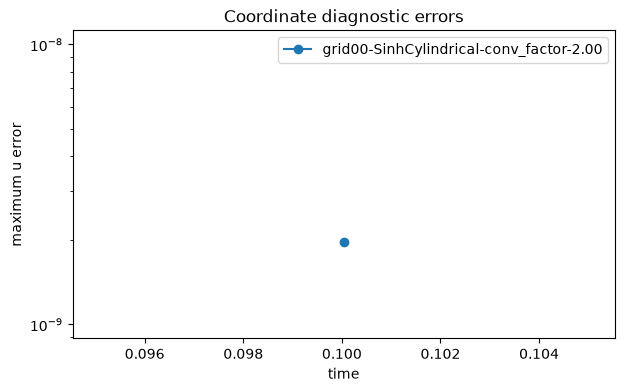

In [16]:
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 4))
for diagnostic in diagnostics:
    rows = [
        [float(value) for value in line.split()]
        for line in diagnostic.read_text(
            encoding="utf-8", errors="replace"
        ).splitlines()
        if line.strip() and not line.lstrip().startswith("#")
    ]
    positive_rows = [row for row in rows if row[1] > 0.0]
    times = [row[0] for row in positive_rows]
    errors = [row[1] for row in positive_rows]
    label = diagnostic.stem.replace("out0d-", "")
    plt.plot(times, errors, marker="o", label=label)
plt.yscale("log")
plt.xlabel("time")
plt.ylabel("maximum u error")
plt.title("Coordinate diagnostic errors")
plt.legend()
plt.show()

The symbolic residuals check the curvilinear wave operator, and the generated project output shows the same operator inside a compiled multi-file code. The runtime parameter file is the one used for the displayed diagnostics.


## Learning Check

Before the spherical residual, identify which terms come from radial derivatives and which come from angular geometry. Then check whether the residual is zero.


## Continue to Boundary Conditions
- [Reference-Metric Applications](../4-curvilinear/reference_metric_applications.ipynb)
- [Basis Transforms](../4-curvilinear/basis_transforms.ipynb)
- [Curvilinear Boundary Conditions](../4-curvilinear/curvilinear_boundary_conditions.ipynb)
- [GeneralRFM and Fisheye Coordinates](../4-curvilinear/generalrfm_and_fisheye.ipynb)
